# Second Frame CCD behaviour
- is our second frame hamiltonian correct?
- or is there some other frame issues going on with rootx?

## Their hamiltonian is correct - so there was something else going on with root x


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import hamiltonians as hamiltonians
from pauli_matrices import *
import quantum_tools as qt

In [14]:
# Create a quantum system with a single qubit
natural_freq = 10 # this is 10Ghz
driving_freq = 10
rabi_freq = 0.005 # this is 5Mhz

# note that we are setting phase_freq to rabi_freq/16
# we are also setting theta_m to pi2
# as well as phi_0 
phi_0, epsilon_m, phase_freq, theta_m = np.pi/2, rabi_freq/16, rabi_freq, np.pi/2

# Integration parameters
tol = 10**-7
evaluation_points = 2000
evaluation_time = 16/rabi_freq

In [15]:
def ccd_second_frame(epsilon_m, rabi_freq, theta_m, phi_0, t):
    """
    Second-order rotating-frame Hamiltonian H_rot^(2)(t).
    All frequencies should be in Hz.
    """
    epsilon_m = 2*np.pi*epsilon_m
    rabi_omega = 2*np.pi*rabi_freq

    cos_theta_m = np.cos(theta_m)
    sin_theta_m = np.sin(theta_m)
    cos_phi_mw = np.cos(phi_0)
    sin_phi_mw = np.sin(phi_0)

    cos_2omega_t = np.cos(2 * rabi_omega * t - theta_m)
    sin_2omega_t = np.sin(2 * rabi_omega * t - theta_m)

    H_static = (epsilon_m / 2) * (cos_theta_m * sigma_z + sin_theta_m * (-sin_phi_mw * sigma_x + cos_phi_mw * sigma_y))
    H_dynamic = (epsilon_m / 2) * (cos_2omega_t * sigma_z + sin_2omega_t * (-sin_phi_mw * sigma_x + cos_phi_mw * sigma_y))

    return  H_static + H_dynamic

In [16]:
times, Us_first_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, 
                                          hamiltonians.ccd_rwa,
                                          natural_freq=natural_freq,
                                          driving_freq=driving_freq,
                                          rabi_freq=rabi_freq,
                                          phase_freq=phase_freq,
                                          phi_0=phi_0,
                                          epsilon_m=epsilon_m,
                                          theta_m=theta_m)



times, Us_second_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, 
                                               ccd_second_frame,
                                               rabi_freq=rabi_freq,
                                               phi_0=phi_0,
                                               epsilon_m=epsilon_m,
                                               theta_m=theta_m)


In [17]:
def U_transform(phase_freq, phi_0, t):
    # half‐angle parameter #
    theta = -np.pi * phase_freq * t
    n_x = np.cos(phi_0)
    n_y = np.sin(phi_0)
    # build the unitary via the Pauli identity
    return (np.cos(theta) * np.eye(2) -1j * np.sin(theta) * (n_x * sigma_x + n_y * sigma_y))


# Transform the unitaries to the new frame
transformed_unitaries = []
for i, t in enumerate(times):
    U_transform_matrix = U_transform(phase_freq, phi_0, t)
    U_transformed = U_transform_matrix @ Us_first_frame[i] 
    transformed_unitaries.append(U_transformed)



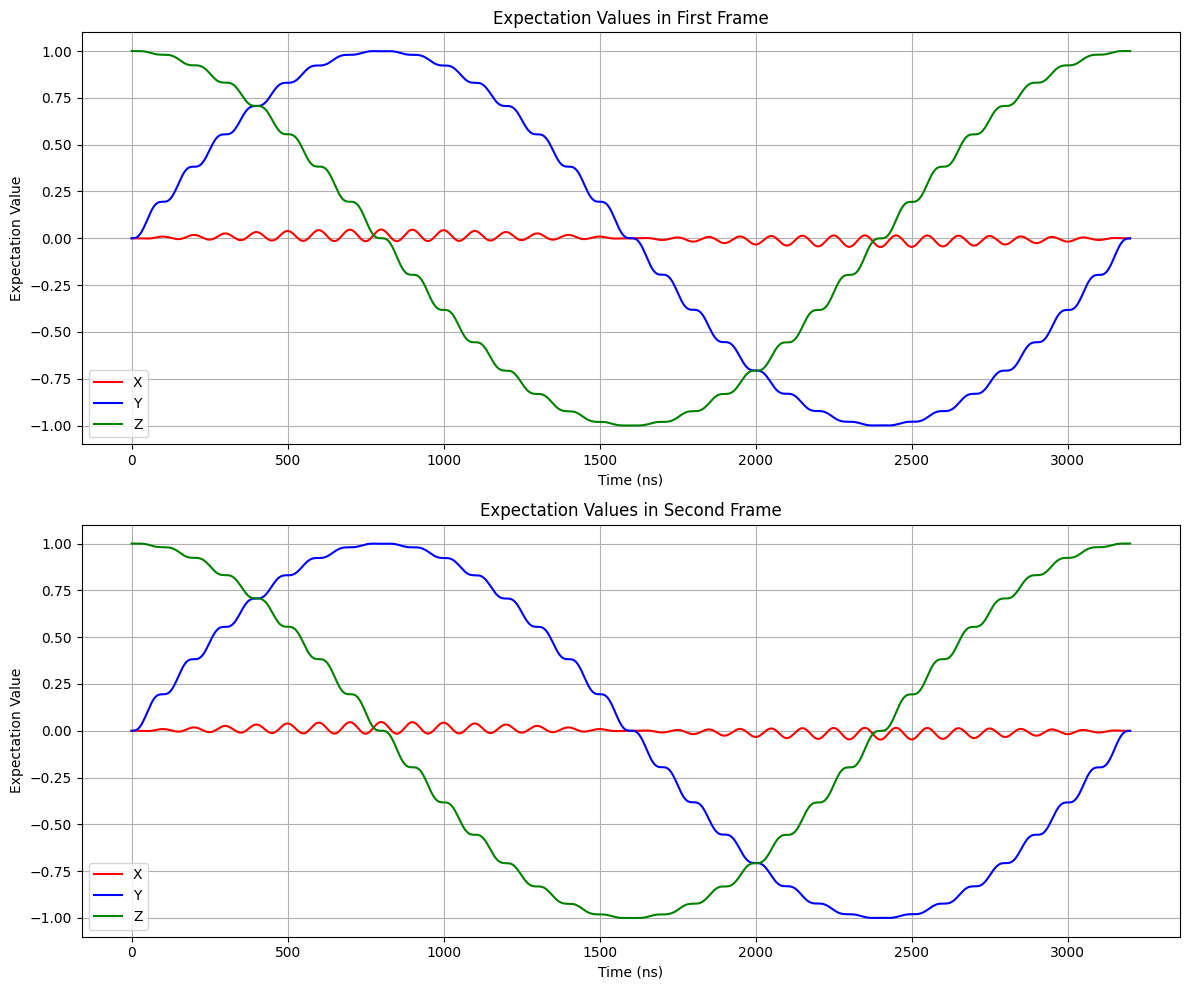

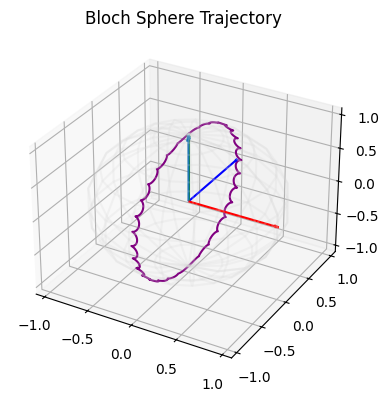

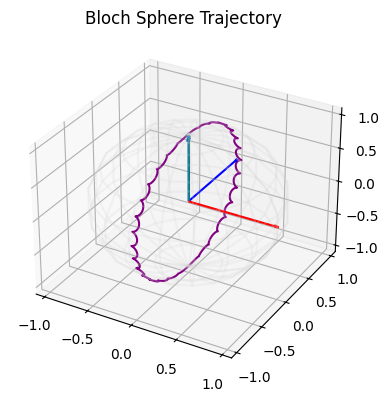

In [18]:

# Define the initial state as |0⟩
initial_state = np.array([1+0j, 0+0j])

# Calculate states for first frame using transformed unitaries
first_frame_states = []
for U in transformed_unitaries:
    state = U @ initial_state
    first_frame_states.append(state)
first_frame_states = np.array(first_frame_states)

# Calculate expectations for first frame
first_x = np.real(qt.calculate_expectations(first_frame_states, sigma_x))
first_y = np.real(qt.calculate_expectations(first_frame_states, sigma_y))
first_z = np.real(qt.calculate_expectations(first_frame_states, sigma_z))

# Calculate states for second frame
second_frame_states = []
for U in Us_second_frame:
    state = U @ initial_state
    second_frame_states.append(state)
second_frame_states = np.array(second_frame_states)

# Calculate expectations for second frame
second_x = np.real(qt.calculate_expectations(second_frame_states, sigma_x))
second_y = np.real(qt.calculate_expectations(second_frame_states, sigma_y))
second_z = np.real(qt.calculate_expectations(second_frame_states, sigma_z))

# Plot the expectations for both frames
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# First frame
axs[0].plot(times, first_x, label='X', color='red')
axs[0].plot(times, first_y, label='Y', color='blue')
axs[0].plot(times, first_z, label='Z', color='green')
axs[0].set_title('Expectation Values in First Frame')
axs[0].set_xlabel('Time (ns)')
axs[0].set_ylabel('Expectation Value')
axs[0].legend()
axs[0].grid(True)

# Second frame
axs[1].plot(times, second_x, label='X', color='red')
axs[1].plot(times, second_y, label='Y', color='blue')
axs[1].plot(times, second_z, label='Z', color='green')
axs[1].set_title('Expectation Values in Second Frame')
axs[1].set_xlabel('Time (ns)')
axs[1].set_ylabel('Expectation Value')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# Also create a 3D visualization of the Bloch sphere trajectories

qt.visualise_solution(times, first_frame_states)
qt.visualise_solution(times, second_frame_states)

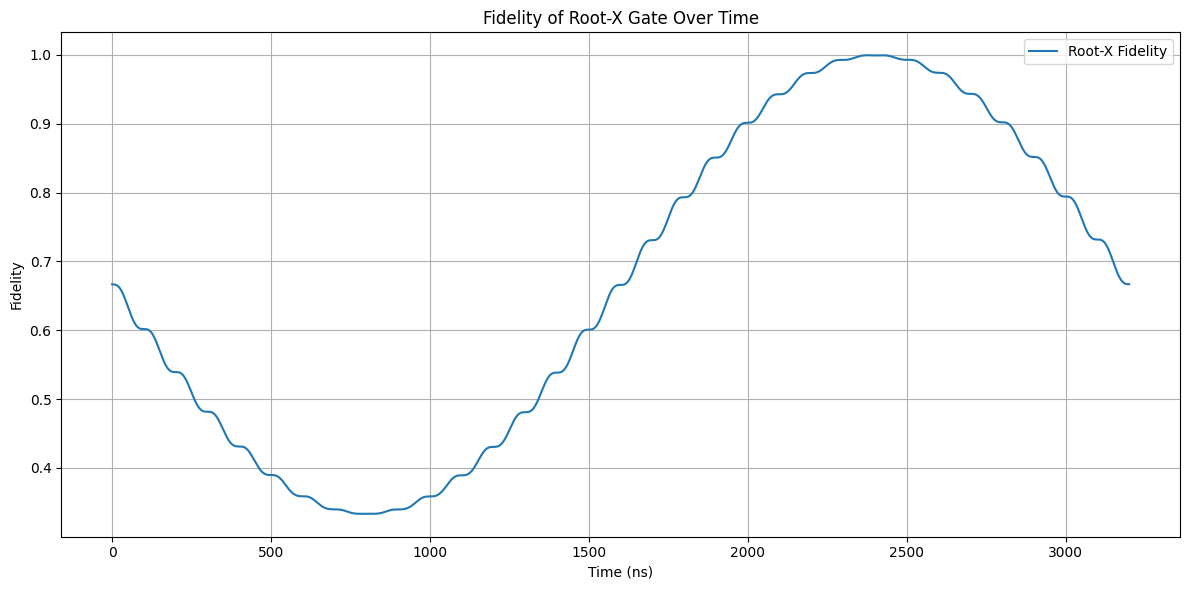

Maximum fidelity: 0.99954233
Time of maximum fidelity: 2375.59 ns


In [19]:
# Calculate fidelity of root-X gate
root_x = (1 / np.sqrt(2)) * np.array([[1, -1j], [-1j, 1]])
fid = qt.calculate_fidelities(root_x, Us_second_frame, 2)

# Plot the fidelity over time
plt.figure(figsize=(12, 6))
plt.plot(times, fid, label='Root-X Fidelity')

plt.title('Fidelity of Root-X Gate Over Time')
plt.xlabel('Time (ns)')
plt.ylabel('Fidelity')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Find the time and value of maximum fidelity
max_fid_idx = np.argmax(fid)
max_fid = fid[max_fid_idx]
max_fid_time = times[max_fid_idx]

print(f"Maximum fidelity: {max_fid:.8f}")
print(f"Time of maximum fidelity: {max_fid_time:.2f} ns")

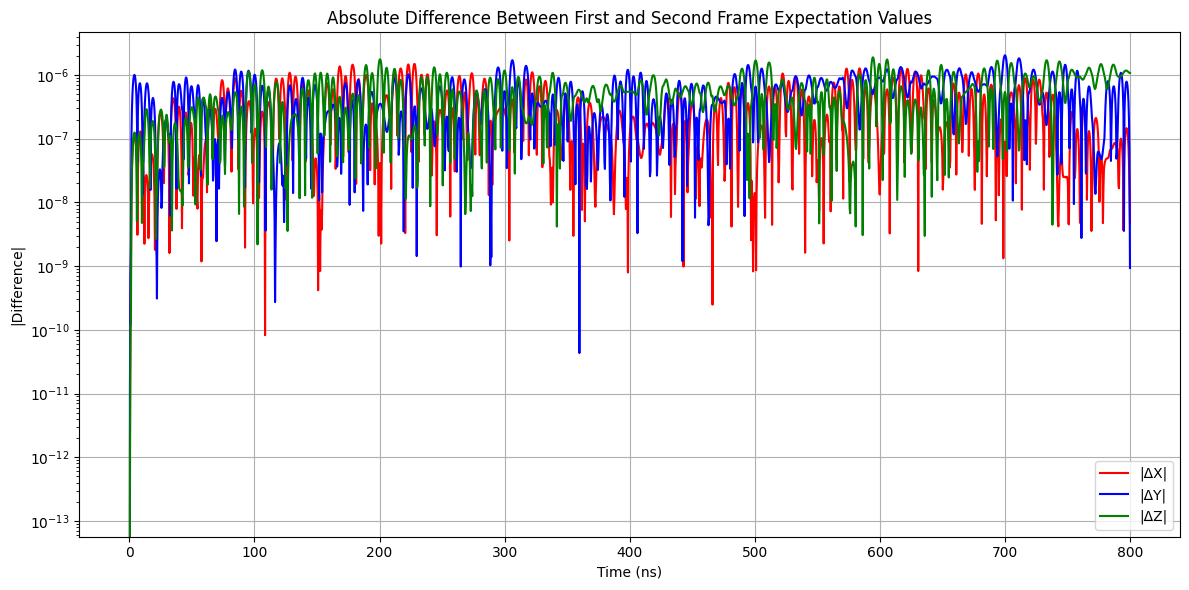

Mean absolute difference - X: 3.17089590e-07
Mean absolute difference - Y: 4.89840847e-07
Mean absolute difference - Z: 5.20559223e-07


In [7]:
# Calculate the absolute difference between first frame and second frame states
diff_x = np.abs(first_x - second_x)
diff_y = np.abs(first_y - second_y)
diff_z = np.abs(first_z - second_z)

plt.figure(figsize=(12, 6))
plt.plot(times, diff_x, label='|ΔX|', color='red')
plt.plot(times, diff_y, label='|ΔY|', color='blue')
plt.plot(times, diff_z, label='|ΔZ|', color='green')

plt.title('Absolute Difference Between First and Second Frame Expectation Values')
plt.xlabel('Time (ns)')
plt.ylabel('|Difference|')
plt.yscale('log')  # Using log scale to better visualize small differences
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate the mean absolute difference for each component
mean_diff_x = np.mean(diff_x)
mean_diff_y = np.mean(diff_y)
mean_diff_z = np.mean(diff_z)

print(f"Mean absolute difference - X: {mean_diff_x:.8e}")
print(f"Mean absolute difference - Y: {mean_diff_y:.8e}")
print(f"Mean absolute difference - Z: {mean_diff_z:.8e}")